Connected to .venv (Python 3.11.13)

### This notebook reproduces all the graphs included in our paper

In [2]:
import numpy as np
from typing import List, Dict, Optional, Tuple, Set, Any
import pandas as pd
from pydantic import BaseModel
from ssa.tasks.task import TaskRunner, TaskBase, ProxyAgent, ProxyTask
from copy import deepcopy
from ssa.agents import (
    AgentHistory,
    AgentActionResponse,
    AgentBase,
    MarketInfo,
    StaticAgent,
    LLMAgent,
    OracleAgent,
    AgentLog,
)
from loguru import logger
import asyncio

from ssa.utils import format_dict_str
from ssa.plotting import plot_agent_trace, plot_allocation

from ssa.tasks.cipher import CipherTask
from ssa.market import RoundData, ExperimentLog

import matplotlib.pyplot as plt
import os

from collections import defaultdict

import numpy as np

def compute_trace_means(traces):
    time_values = defaultdict(list)
    [time_values[t].append(v) for trace in traces for t, v in trace if v < 2]
    return np.array([(t, float(np.mean(vs))) for t, vs in sorted(time_values.items())])

def interp_trace(trace):
    times, values = zip(*trace)
    return np.interp(np.arange(100), times, values)

In [3]:
# Baseline experiments
logs = []
for f in os.listdir('logs'):
    if "llm_baseline_full" in f:
        try:
            logs.append(ExperimentLog.load(f"logs/{f}"))
        except:
            print(f)
            continue


In [ ]:
df = pd.concat([pd.DataFrame([dict(run=ix, agent_id=agent.id, reward=agent.total_reward, atype=agent.id.split("-")[0]) for agent in l.agents]) for ix, l in enumerate(logs)])
# Calculate mean reward per agent type per run
df_run_means = (df.groupby(["atype", "run"])
                .mean(numeric_only=True)
                .reset_index())

# Add ranking within each run (1 = best performance)
df_run_means['rank'] = (df_run_means.groupby('run')['reward']
                        .rank(ascending=False, method='average'))

# Calculate summary statistics
results = (df_run_means.groupby("atype")
           .agg({
               'reward': ['mean', 'std'],
               'rank': 'mean'
           })
           .round(2))

results_transposed = results.T

print("Results:")
print(results_transposed)

latex_transposed = results_transposed.to_latex(
    formatters={col: '{:.1f}'.format if 'reward' in col else '{:.2f}'.format 
                for col in results_transposed.columns},
    caption='Agent Performance Summary (Transposed)',
    label='tab:agent_performance_transposed'
)
print(latex_transposed)

Transposed Results:
atype         FIXPL   GRDPL  deepseek     glm    goog    goss    gpt5    kimi  \
reward mean  374.68  283.57    457.58  649.21  493.77  726.92  703.01  442.69   
       std   316.14  334.14    343.12  397.36  371.60  384.84  565.98  298.35   
rank   mean    6.11    7.22      5.60    4.10    5.30    3.10    4.70    5.30   

atype         llama    qwen  
reward mean  212.45  587.00  
       std   361.25  505.86  
rank   mean    8.30    4.70  

Transposed LaTeX Table:
\begin{table}
\caption{Agent Performance Summary (Transposed)}
\label{tab:agent_performance_transposed}
\begin{tabular}{llrrrrrrrrrr}
\toprule
 & atype & FIXPL & GRDPL & deepseek & glm & goog & goss & gpt5 & kimi & llama & qwen \\
\midrule
\multirow[t]{2}{*}{reward} & mean & 374.68 & 283.57 & 457.58 & 649.21 & 493.77 & 726.92 & 703.01 & 442.69 & 212.45 & 587.00 \\
 & std & 316.14 & 334.14 & 343.12 & 397.36 & 371.60 & 384.84 & 565.98 & 298.35 & 361.25 & 505.86 \\
\cline{1-12}
rank & mean & 6.11 & 7.22 & 5.

## Price Analysis (Open v.s. Sealed Bids)

In [5]:
price_logs = []
non_price_logs = []
for f in os.listdir('logs'):
    if "llm_baseline_full_p" in f and "price" in f: 
        price_logs.append(ExperimentLog.load(f"logs/{f}"))
    if "llm_baseline_full_p" in f and "price" not in f: 
        non_price_logs.append(ExperimentLog.load(f"logs/{f}"))

In [15]:
price_traces

[array([0.92      , 0.92      , 0.92      , 0.92      , 0.882     ,
        0.876     , 0.875     , 0.86666667, 0.86666667, 0.85      ,
        0.86666667, 0.86666667, 0.86666667, 0.87361111, 0.88055556,
        0.8875    , 0.86666667, 0.86666667, 0.86666667, 0.86666667,
        0.86666667, 0.85      , 0.875     , 0.9       , 0.825     ,
        0.85      , 0.85      , 0.8875    , 0.8625    , 0.86666667,
        0.9       , 0.86666667, 0.86666667, 0.85      , 0.85833333,
        0.86666667, 0.86666667, 0.86666667, 0.86666667, 0.86666667,
        0.86666667, 0.9       , 0.86666667, 0.86666667, 0.86666667,
        0.85      , 0.85833333, 0.86666667, 0.85      , 0.865     ,
        0.88      , 0.8375    , 0.9       , 0.86666667, 0.85      ,
        0.86666667, 0.85      , 0.86666667, 0.86666667, 0.85      ,
        0.87      , 0.85      , 0.89333333, 0.87166667, 0.85      ,
        0.86666667, 0.86666667, 0.86666667, 0.86666667, 0.86666667,
        0.86666667, 0.66666667, 0.77083333, 0.87

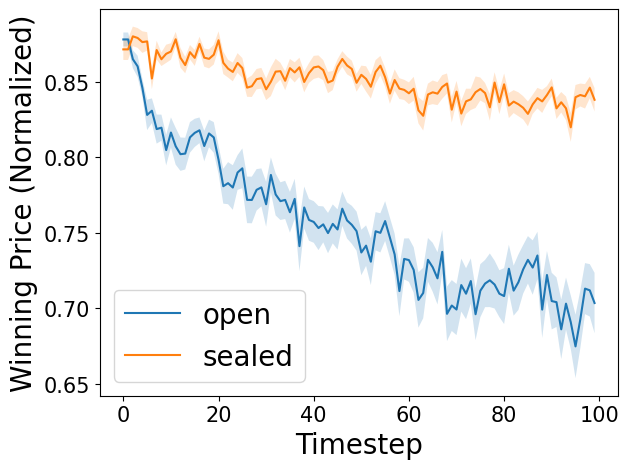

In [23]:
non_traces = []

for l in non_price_logs:
    for j in l.job_ids:
        t = compute_trace_means(l.agent_bids_normalized[j])
        non_traces.append(interp_trace(t))
price_traces = []

for l in price_logs:
    for j in l.job_ids:
        t = compute_trace_means(l.agent_bids_normalized[j])
        price_traces.append(interp_trace(t))

plt.plot()

psem = np.array(price_traces).std(axis=0) / np.sqrt(len(price_traces))
pmean = np.mean(price_traces, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, alpha=0.2)
plt.plot(np.arange(100), np.mean(price_traces, axis=0), label='open')


psem = np.array(non_traces).std(axis=0) / np.sqrt(len(non_traces))
pmean = np.mean(non_traces, axis=0)

plt.fill_between(np.arange(100),pmean - psem, pmean + psem, alpha=0.2)
plt.plot(np.arange(100), np.mean(non_traces, axis=0), label='sealed')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Winning Price (Normalized)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()


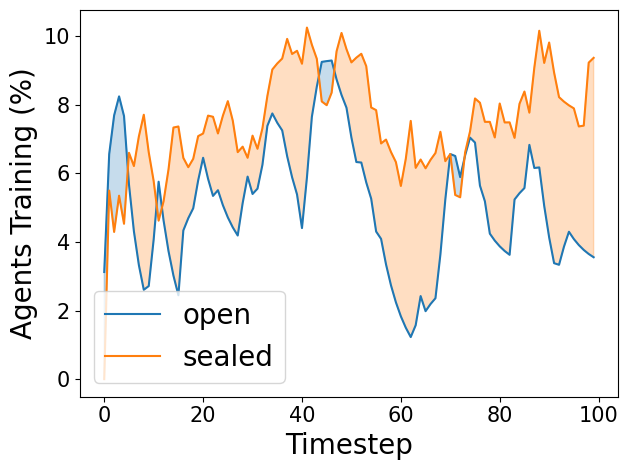

In [28]:
price_skill = []
for experiment in price_logs:
    price_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions[:-2]]) for hx in experiment.history]))
period = 10
n_agents = 8

non_price_skill = []
for experiment in non_price_logs:
    non_price_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions[:-2]]) for hx in experiment.history]))

prc = pd.Series(np.mean(price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc =  pd.Series(np.mean(non_price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

plt.plot(prc, label='open')
plt.plot(noprc, label='sealed')

plt.fill_between(
    np.arange(100),prc, noprc, where=(prc > noprc), 
    interpolate=True, color="tab:blue", alpha=0.25, 
)

plt.fill_between(
    np.arange(100),prc, noprc, where=(noprc > prc), 
    interpolate=True, color="tab:orange", alpha=0.25,
)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()

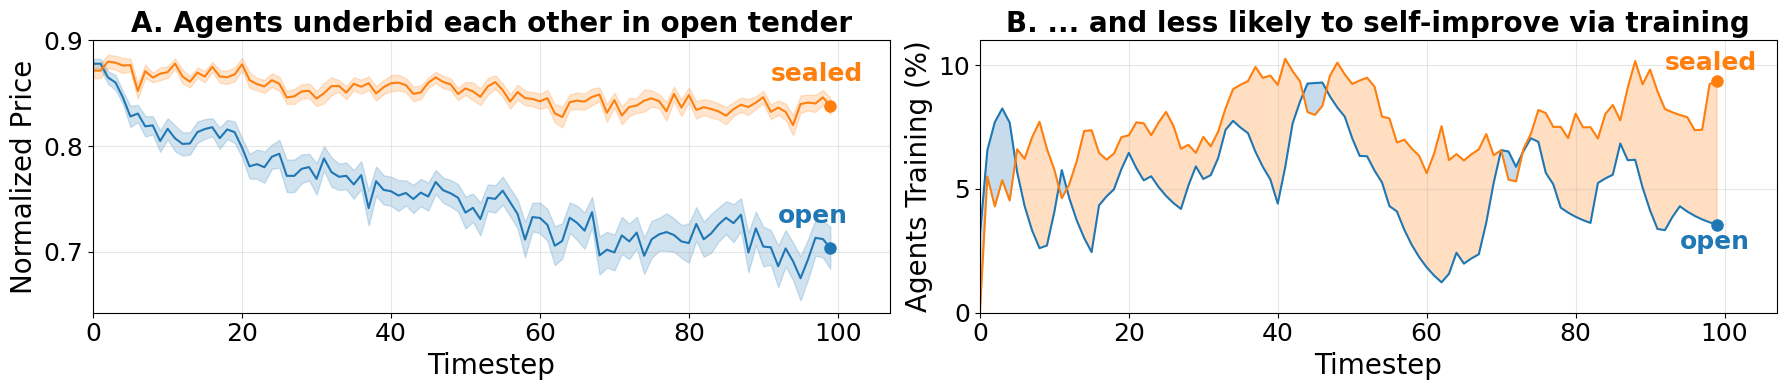

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4), sharex=True)

# First subplot - Winning Price
psem = np.array(price_traces).std(axis=0) / np.sqrt(len(price_traces))
pmean = np.mean(price_traces, axis=0)

ax1.fill_between(np.arange(100), pmean - psem, pmean + psem, alpha=0.2, color='tab:blue')
ax1.plot(np.arange(100), pmean, markevery=[-1], marker='o', markersize=8, color='tab:blue')

psem = np.array(non_traces).std(axis=0) / np.sqrt(len(non_traces))
pmean_non = np.mean(non_traces, axis=0)

ax1.fill_between(np.arange(100), pmean_non - psem, pmean_non + psem, alpha=0.2, color='tab:orange')
ax1.plot(np.arange(100), pmean_non, markevery=[-1], marker='o', markersize=8, color='tab:orange')

ax1.set_ylabel("Normalized Price", fontsize=20)
ax1.set_xlabel("Timestep", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 105)  # Extend to accommodate legend text

# Position legend text near end points
ax1.text(92, pmean[-1] + 0.03, 'open', fontsize=18, va='center', color='tab:blue', weight='bold')
ax1.text(91, pmean_non[-1] + 0.03, 'sealed', fontsize=18, va='center', color='tab:orange', weight='bold')
ax1.set_yticks([0.7, 0.8, 0.9])
ax1.set_title("A. Agents underbid each other in open tender", fontsize=20, weight='bold')


# Second subplot - Agent Training
prc = pd.Series(np.mean(price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()
noprc = pd.Series(np.mean(non_price_skill, axis=0)/n_agents*100).ewm(span=period).mean().to_numpy()

ax2.plot(prc, markevery=[-1], marker='o', markersize=8, color='tab:blue')
ax2.plot(noprc, markevery=[-1], marker='o', markersize=8, color='tab:orange')

ax2.fill_between(
    np.arange(100), prc, noprc, where=(prc > noprc), 
    interpolate=True, color="tab:blue", alpha=0.25, 
)

ax2.fill_between(
    np.arange(100), prc, noprc, where=(noprc > prc), 
    interpolate=True, color="tab:orange", alpha=0.25,
)

ax2.set_ylabel("Agents Training (%)", fontsize=20)
ax2.set_xlabel("Timestep", fontsize=20)
ax2.set_yticks([0, 5, 10])
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 107)  # Extend to accommodate legend text
ax2.set_ylim(0, 11)
ax2.set_title("B. ... and less likely to self-improve via training", fontsize=20, weight='bold')

# Position legend text near end points
ax2.text(94, prc[-1]-0.7, 'open', fontsize=18, va='center', color='tab:blue', weight='bold')
ax2.text(92, noprc[-1]+0.7, 'sealed', fontsize=18, va='center', color='tab:orange', weight='bold')

plt.tight_layout()
plt.show()


# LLM v.s. SSA

In [ ]:
# Analysis on changing price sensitivity
price_points = []
actions = []
for i in range(4):
    filepath = f'logs/wq/wq_exp_{i}.log'
    exp_log = ExperimentLog.load(filepath)

    for j in exp_log.job_ids:
        for agent_id, pp in zip(exp_log.agent_ids, exp_log.agent_bids_normalized[j]):
            job_type = j[3]
            for p in pp:
                tp, p = p
                price_points.append(dict(agent_id=agent_id, agent_type=agent_id[:3], task=job_type, step=tp, price=p))
    
    actions.append([[action.targets for action in hx.agent_actions if action.action == 'train'] for hx in exp_log.history])
    # price_traces.append(interp_trace(t))

In [ ]:
df = pd.DataFrame(price_points)
df.groupby(['task', 'agent_type']).mean(numeric_only=True)

step     price
task agent_type                     
A    L2M         43.416667  0.787491
     SSA         48.532249  0.741800
B    L2M         47.458295  0.816184
     SSA         42.179185  0.728643
C    L2M         45.955801  0.853457
     SSA         47.222222  0.717297
D    L2M         46.227610  0.895510
     SSA         45.232444  0.825234

In [ ]:
skill_counts = []
for a in actions:
    for _a in a:
        for __a in _a:
            skill_counts.append(__a[0][0])

from collections import Counter

Counter(skill_counts)

Counter({'SK-C': 178, 'SK-D': 156, 'SK-B': 99, 'SK-A': 86})

In [ ]:
filepath = 'logs/market_recession_ssa2_3.log'
exp_log = ExperimentLog.load(filepath)

In [ ]:
ssa_skill = []
ssa_skill.append(np.array([np.sum([a.action == 'train' for a in hx.agent_actions]) for hx in exp_log.history]))

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Timestep', ylabel='Agents performing training (%)'>)

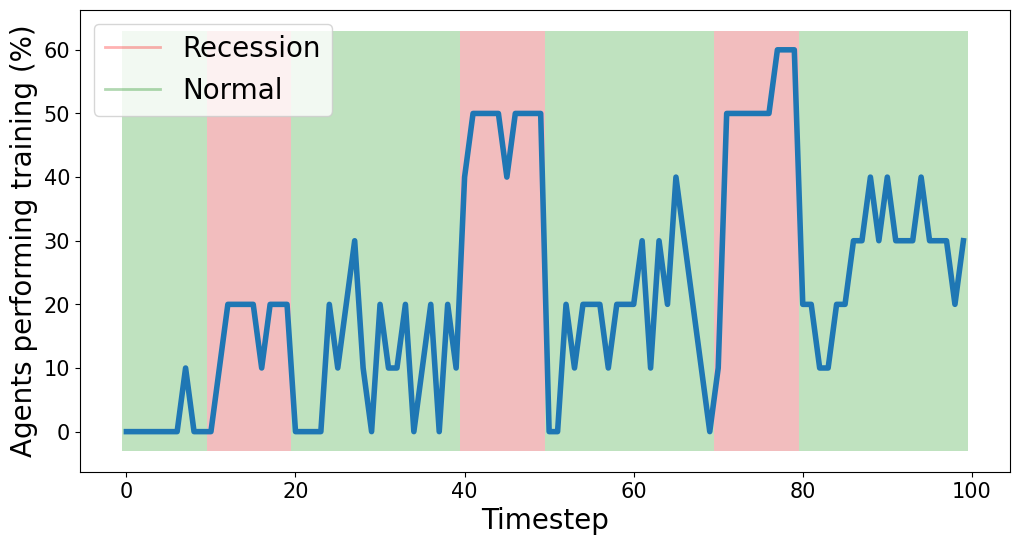

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_bool_regions_with_line(bool_array, float_array, x=None):
    if x is None:
        x = np.arange(len(bool_array))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot line first to get proper y-limits
    ax.plot(x, float_array, color='tab:blue', linewidth=4, zorder=3)
    ymin, ymax = ax.get_ylim()
    
    # Create rectangles for each boolean value
    for i, is_true in enumerate(bool_array):
        color = 'tab:red' if is_true else 'tab:green'
        rect = patches.Rectangle((i-0.5, ymin), 1, ymax-ymin, facecolor=color, alpha=0.3, zorder=1)
        ax.add_patch(rect)
    
    # Add legend manually (since rectangles don't auto-legend well)
    ax.plot([], [], color='red', alpha=0.3, linewidth=2, label='Recession')
    ax.plot([], [], color='green', alpha=0.3, linewidth=2, label='Normal')
    
    ax.set_xlabel('Timestep', fontsize=20)
    ax.set_ylabel('Agents performing training (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)

    ax.legend(fontsize=20)

    return fig, ax

recession = [True if (round_ix // 10) % 3 == 1 else False for round_ix in range(100)]

plot_bool_regions_with_line(np.array(recession), ssa_skill[0] * 10)

In [ ]:
# Analysis on changing market conditions
filepath = 'logs/market_change_0.log'
exp_log = ExperimentLog.load(filepath)

In [ ]:
agent_rewards = np.array([h.agent_round_rewards for h in experiment.history])

plt.plot(np.cumsum(agent_rewards, axis=0), label=experiment.agent_ids)
plt.legend()

NameError: name 'experiment' is not defined

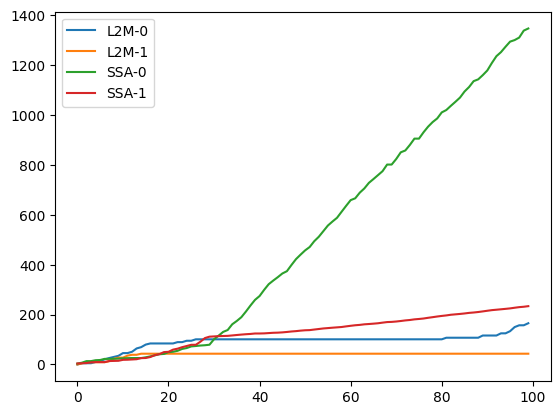

In [ ]:
agent_rewards = np.array([h.agent_round_rewards for h in exp_log.history])

plt.plot(np.cumsum(agent_rewards, axis=0), label=exp_log.agent_ids)
plt.legend()

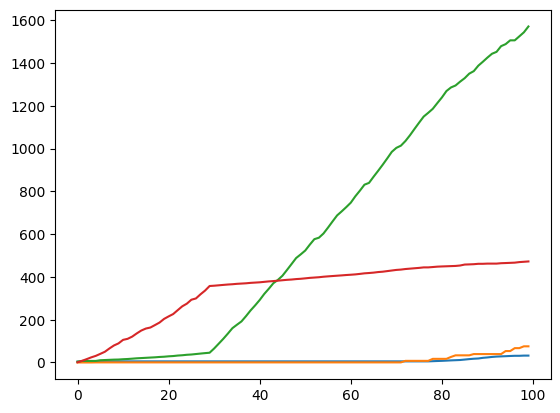

In [ ]:
plt.plot(np.cumsum(exp_log.agent_reward_history.T, axis=0))

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Timestep', ylabel='Agents performing training (%)'>)

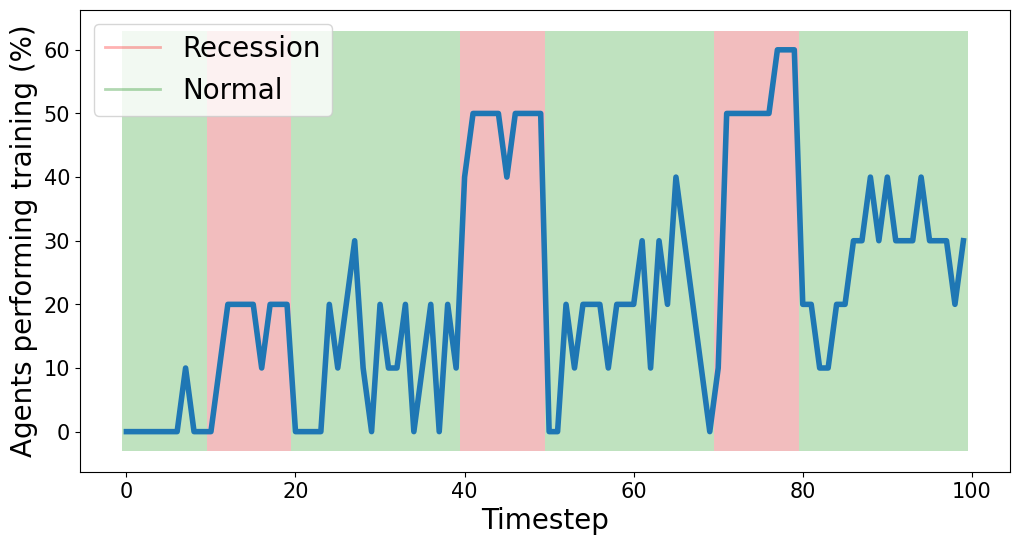

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_bool_regions_with_line(bool_array, float_array, x=None):
    if x is None:
        x = np.arange(len(bool_array))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot line first to get proper y-limits
    ax.plot(x, float_array, color='tab:blue', linewidth=4, zorder=3)
    ymin, ymax = ax.get_ylim()
    
    # Create rectangles for each boolean value
    for i, is_true in enumerate(bool_array):
        color = 'tab:red' if is_true else 'tab:green'
        rect = patches.Rectangle((i-0.5, ymin), 1, ymax-ymin, facecolor=color, alpha=0.3, zorder=1)
        ax.add_patch(rect)
    
    # Add legend manually (since rectangles don't auto-legend well)
    ax.plot([], [], color='red', alpha=0.3, linewidth=2, label='Recession')
    ax.plot([], [], color='green', alpha=0.3, linewidth=2, label='Normal')
    
    ax.set_xlabel('Timestep', fontsize=20)
    ax.set_ylabel('Agents performing training (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)

    ax.legend(fontsize=20)

    return fig, ax

recession = [True if (round_ix // 10) % 3 == 1 else False for round_ix in range(100)]

plot_bool_regions_with_line(np.array(recession), ssa_skill[0] * 10)

In [ ]:
agent_rewards = np.array([h.agent_round_rewards for h in exp_log.history])

agent_train_targets = []
agent_bid_targets = []
for j in range(5):
    filepath = f'logs/market_change_{j}.log'
    exp_log = ExperimentLog.load(filepath)
    for i in range(4):
        agent_history = [a for a in exp_log.agents[i].agent_history]
        for hx in agent_history:
            ix = hx.round
            agent_action = hx.agent_action
            if agent_action.action == 'train':
                if i <= 2: 
                    agent_type = 'l2m'
                else:
                    agent_type = 'ssa'
                agent_train_targets.append((ix, agent_type, agent_action.targets[0][0]))
            elif agent_action.action == 'bid':
                for rank, target in enumerate(agent_action.targets):
                    agent_bid_targets.append((ix, agent_type, target[0], target[0][:4], rank))

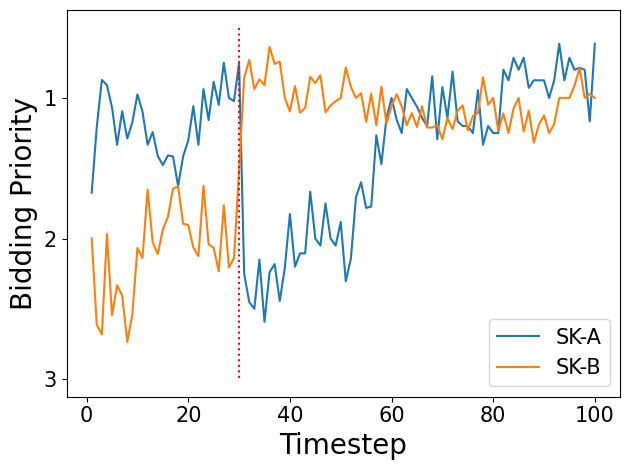

In [ ]:
bid_trace = pd.DataFrame(agent_bid_targets, columns=['round_id', 'agent_type', 'bid', 'job_type', 'rank'])
bid_trace = bid_trace.groupby(['round_id', 'job_type']).mean(numeric_only=True).reset_index()

trace_a = bid_trace.query('job_type=="JB-A"')
trace_b = bid_trace.query('job_type=="JB-B"')

plt.plot(trace_a['round_id'], trace_a['rank'], label='SK-A')
plt.plot(trace_b['round_id'], trace_b['rank'], label='SK-B')
plt.gca().invert_yaxis()
plt.yticks(np.arange(4), fontsize=15)
plt.xticks(fontsize=15)
ymin, ymax = plt.ylim()

plt.vlines(30, 0.5, 3, linestyles=":", color='red')

plt.ylabel("Bidding Priority", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()

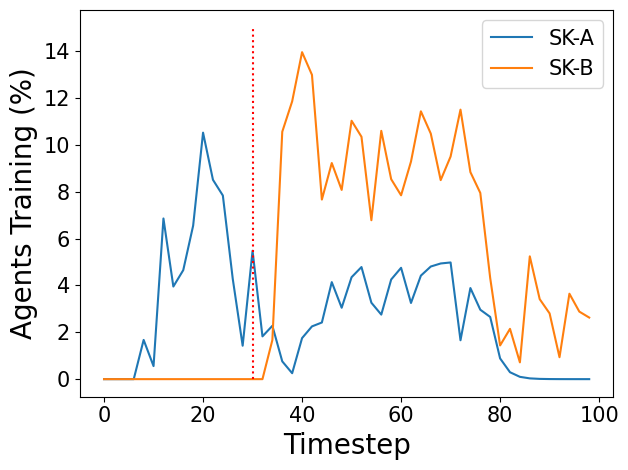

In [ ]:
period=2
smooth = lambda x: pd.Series(x).ewm(span=period).mean()

plt.plot(np.arange(0, 100, 2), smooth(train_trace['SK-A'].reshape(50, 2).mean(axis=1)*5), label='SK-A')
plt.plot(np.arange(0, 100, 2),smooth(train_trace['SK-B'].reshape(50, 2).mean(axis=1)*5), label='SK-B')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Agents Training (%)", fontsize=20)
plt.xlabel("Timestep", fontsize=20)
plt.vlines(30, 0, 15, linestyles=':', color='red')
plt.legend(fontsize=15)
plt.tight_layout()

In [ ]:
df = pd.DataFrame(agent_action_series, columns=['wq', 'round', 'agent_id', 'action'])
df.groupby(['wq', 'agent_id', 'round']).mean().reset_index().groupby(['wq', 'agent_id', df['round'] // 10]).max().groupby('wq').agg({
               'action': ['mean', 'sem'],})

action          
         mean       sem
wq                     
0.1  0.159091  0.055778
0.3  0.272727  0.037967
0.5  0.295455  0.069577
0.7  0.318182  0.071029
0.9  0.431818  0.075537